In [ ]:
# For example, here's several helpful packages to load
%pip install category_encoders
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import KFold, cross_val_score, train_test_split, GridSearchCV
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import sklearn.metrics as metrics

from category_encoders import MEstimateEncoder



In [ ]:
random.seed(0)

In [24]:
train_df = pd.read_csv("train.csv", index_col="id", header=0)
test_df = pd.read_csv("test.csv", index_col="id", header=0)

# EDA

#### initial checks

In [25]:
train_df.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
id,,,,,,,,,,,,
0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


In [26]:
test_df.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
id,,,,,,,,,,,
2190,1,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3
2191,2,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3
2192,3,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9
2193,4,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6
2194,5,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4


In [27]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2190 entries, 0 to 2189
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   day            2190 non-null   int64  
 1   pressure       2190 non-null   float64
 2   maxtemp        2190 non-null   float64
 3   temparature    2190 non-null   float64
 4   mintemp        2190 non-null   float64
 5   dewpoint       2190 non-null   float64
 6   humidity       2190 non-null   float64
 7   cloud          2190 non-null   float64
 8   sunshine       2190 non-null   float64
 9   winddirection  2190 non-null   float64
 10  windspeed      2190 non-null   float64
 11  rainfall       2190 non-null   int64  
dtypes: float64(10), int64(2)
memory usage: 205.4 KB


In [28]:
train_df.isna().sum()

day              0
pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
sunshine         0
winddirection    0
windspeed        0
rainfall         0
dtype: int64

In [29]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 730 entries, 2190 to 2919
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   day            730 non-null    int64  
 1   pressure       730 non-null    float64
 2   maxtemp        730 non-null    float64
 3   temparature    730 non-null    float64
 4   mintemp        730 non-null    float64
 5   dewpoint       730 non-null    float64
 6   humidity       730 non-null    float64
 7   cloud          730 non-null    float64
 8   sunshine       730 non-null    float64
 9   winddirection  729 non-null    float64
 10  windspeed      730 non-null    float64
dtypes: float64(10), int64(1)
memory usage: 62.9 KB


In [30]:
test_df.isna().sum()

day              0
pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
sunshine         0
winddirection    1
windspeed        0
dtype: int64

1 missing value in the test set

check index correctness

In [31]:
print('error in index:',train_df.index.isin(test_df.index).sum())
print('missing train set index:',[i for i in range(0,train_df.shape[0]) if i not in train_df.index])
print('missing test set index:', [i for i in range(train_df.shape[0],train_df.shape[0]+test_df.shape[0]) if i not in test_df.index])

error in index: 0
missing train set index: []
missing test set index: []


check total duplicates

In [32]:
# initial check for duplicates
print('total duplicates:',pd.concat([train_df, test_df]).duplicated().sum())

total duplicates: 0


## Clean Sets

In [34]:
def clean(df):
  df = df.rename(columns={"temparature": "temperature"})
  return df

def impute(df):
    for name in df.select_dtypes("number"):
        df[name] = df[name].fillna(df[name].mean())
    for name in df.select_dtypes("category"):
        df[name] = df[name].fillna("None")
    return df
    
def load_data():
  train_df = pd.read_csv("train.csv", index_col="id", header=0)
  test_df = pd.read_csv("test.csv", index_col="id", header=0)
  #df = pd.concat([train_df, test_df], axis = 0)
  train_df = clean(train_df)
  test_df = clean(test_df)
  # fillin 1 missing value with mean for numeric in test
  test_df = impute(test_df)
  # # check duplicated
  # # df[df.duplicated()].sum()  
  # train_df = remove_outliers(train_df)
  # test_df = remove_outliers(test_df)
  return train_df, test_df

train_df, test_df = load_data()

In [35]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2190 entries, 0 to 2189
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   day            2190 non-null   int64  
 1   pressure       2190 non-null   float64
 2   maxtemp        2190 non-null   float64
 3   temperature    2190 non-null   float64
 4   mintemp        2190 non-null   float64
 5   dewpoint       2190 non-null   float64
 6   humidity       2190 non-null   float64
 7   cloud          2190 non-null   float64
 8   sunshine       2190 non-null   float64
 9   winddirection  2190 non-null   float64
 10  windspeed      2190 non-null   float64
 11  rainfall       2190 non-null   int64  
dtypes: float64(10), int64(2)
memory usage: 205.4 KB


In [36]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 730 entries, 2190 to 2919
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   day            730 non-null    int64  
 1   pressure       730 non-null    float64
 2   maxtemp        730 non-null    float64
 3   temperature    730 non-null    float64
 4   mintemp        730 non-null    float64
 5   dewpoint       730 non-null    float64
 6   humidity       730 non-null    float64
 7   cloud          730 non-null    float64
 8   sunshine       730 non-null    float64
 9   winddirection  730 non-null    float64
 10  windspeed      730 non-null    float64
dtypes: float64(10), int64(1)
memory usage: 62.9 KB


## Check balance of target variable


In [37]:
train_df.rainfall.value_counts(dropna=False, normalize = True)

# the target variable is inbalanced but not extremely so. We will not resample

rainfall
1    0.753425
0    0.246575
Name: proportion, dtype: float64

In [38]:
train_df.describe(include='all')

,day,pressure,maxtemp,temperature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
count,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000
mean,179.948402,1013.602146,26.365799,23.953059,22.170091,20.454566,82.036530,75.721918,3.744429,104.863151,21.804703,0.753425
std,105.203592,5.655366,5.654330,5.222410,5.059120,5.288406,7.800654,18.026498,3.626327,80.002416,9.898659,0.431116
min,1.000000,999.000000,10.400000,7.400000,4.000000,-0.300000,39.000000,2.000000,0.000000,10.000000,4.400000,0.000000
25%,89.000000,1008.600000,21.300000,19.300000,17.700000,16.800000,77.000000,69.000000,0.400000,40.000000,14.125000,1.000000
50%,178.500000,1013.000000,27.800000,25.500000,23.850000,22.150000,82.000000,83.000000,2.400000,70.000000,20.500000,1.000000
75%,270.000000,1017.775000,31.200000,28.400000,26.400000,25.000000,88.000000,88.000000,6.800000,200.000000,27.900000,1.000000
max,365.000000,1034.600000,36.000000,31.500000,29.800000,26.700000,98.000000,100.000000,12.100000,300.000000,59.500000,1.000000


In [39]:
# 4. check which days are represented in the sets
print("missing train days:",[i for i in range(1,366) if i not in train_df.day.unique()])
print("missing test days:", [i for i in range(1,366) if i not in train_df.day.unique()])

missing train days: []
missing test days: []


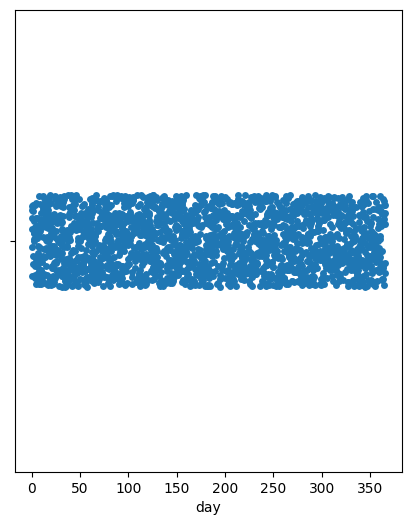

In [ ]:
plt.figure(figsize=(5,6))
# Assigning a single numeric variable shows its univariate distribution with points randomly “jittered”
ax = sns.stripplot(data=train_df, x='day')
plt.show()

In [41]:
X = train_df.copy()
#y = X.pop("rainfall")

## Check variable interaction with visualizations


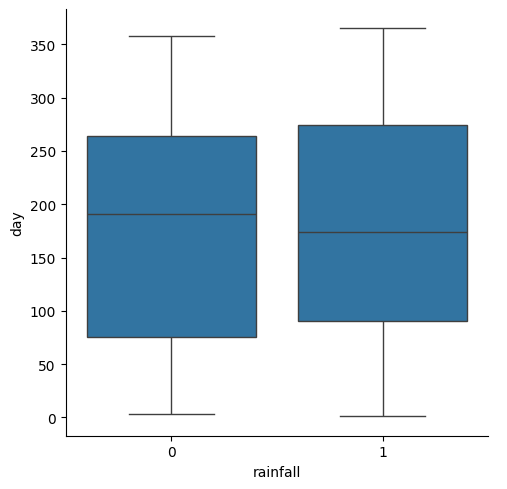

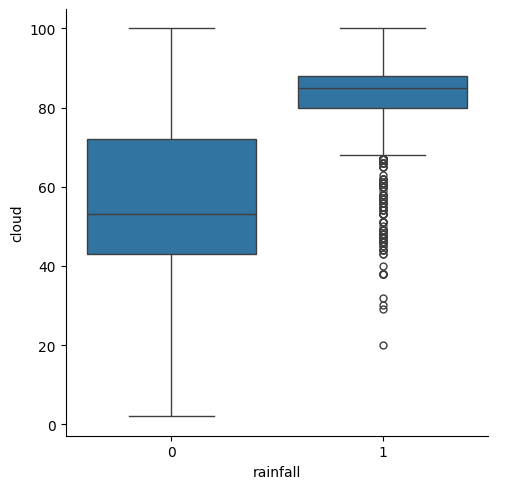

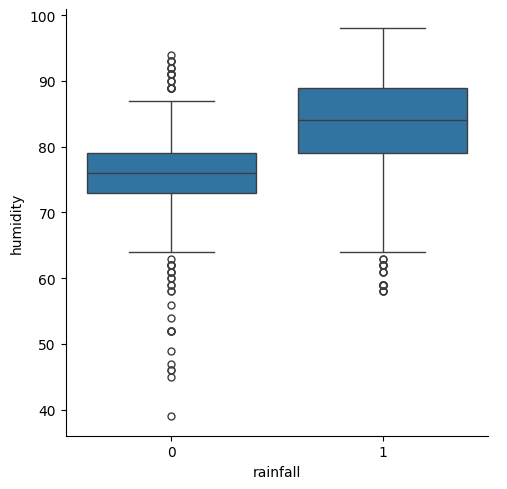

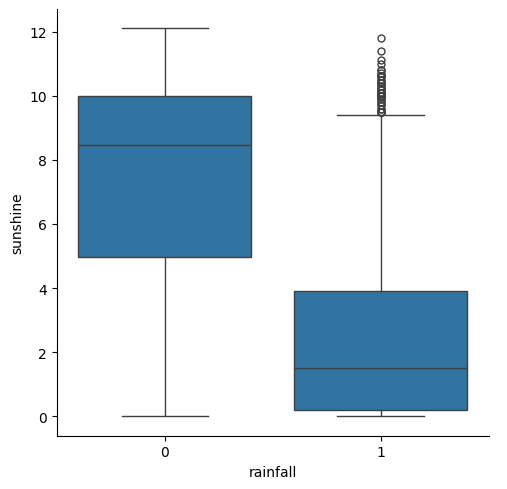

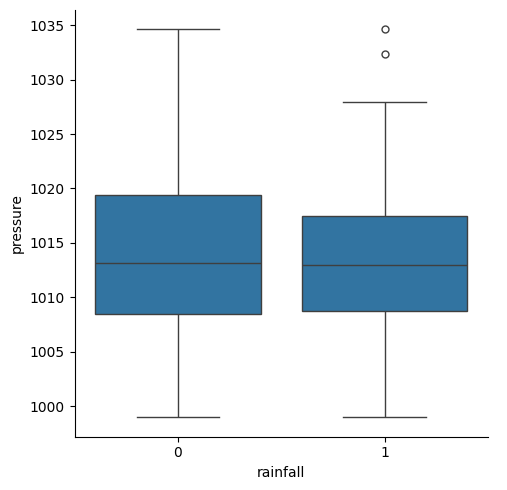

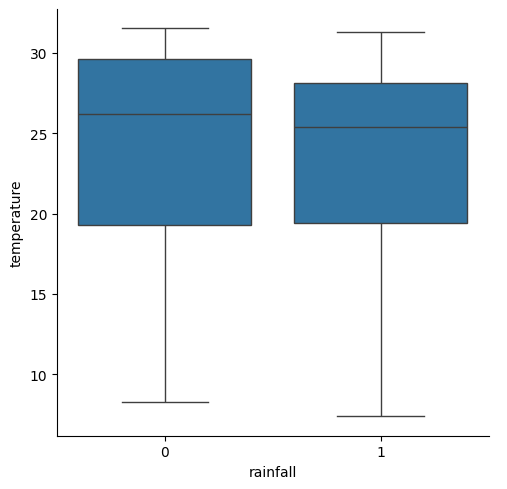

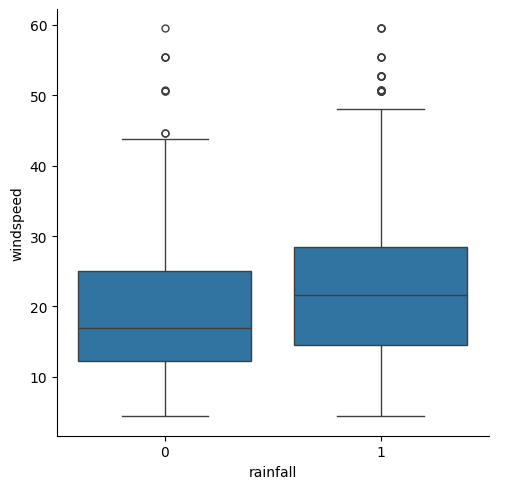

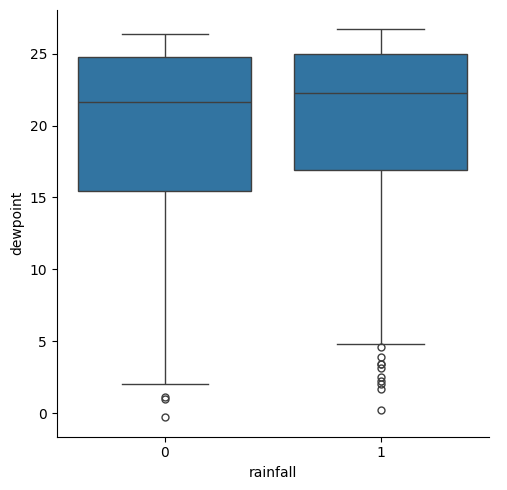

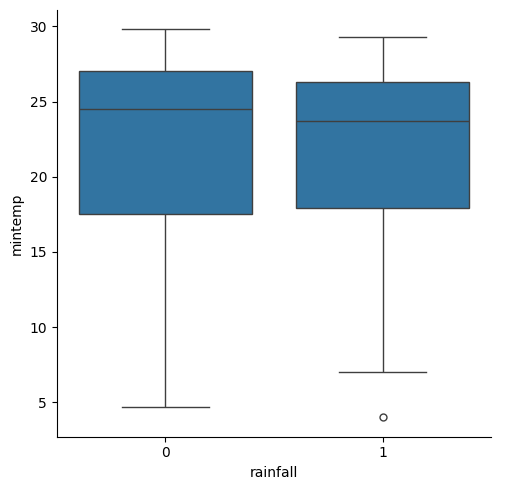

In [45]:

#fig, ax = plt.subplots(8,1, sharey=True)
cols = ["day","cloud","humidity","sunshine","pressure","temperature","windspeed", "dewpoint","mintemp"]
for i,col in enumerate(cols):
    axs = sns.catplot(x="rainfall", y=col, data = X, kind="box")    
plt.tight_layout()
plt.show()

# NOTES:
# there are outliers where there is rain with low cloud and rain with high sunshnine
# there are 3 variables that have different distribution for each targe class: cloud, humidity, sunshine

In [ ]:
 # check outlier values
train_df_rain = train_df[train_df.rainfall == 1]
train_df_rain[(train_df_rain.sunshine > 10) & (train_df_rain.cloud < 60)]

In [47]:
outlier_df = train_df_rain[(train_df_rain.sunshine > 10) & (train_df_rain.cloud < 60)]
outlier_months = pd.to_datetime(outlier_df.day, format="%j").dt.month.value_counts()
outlier_months.index.rename("Outlier Month Count", inplace=True)
outlier_months

Outlier Month Count
7    9
6    5
9    4
5    1
8    1
Name: count, dtype: int64

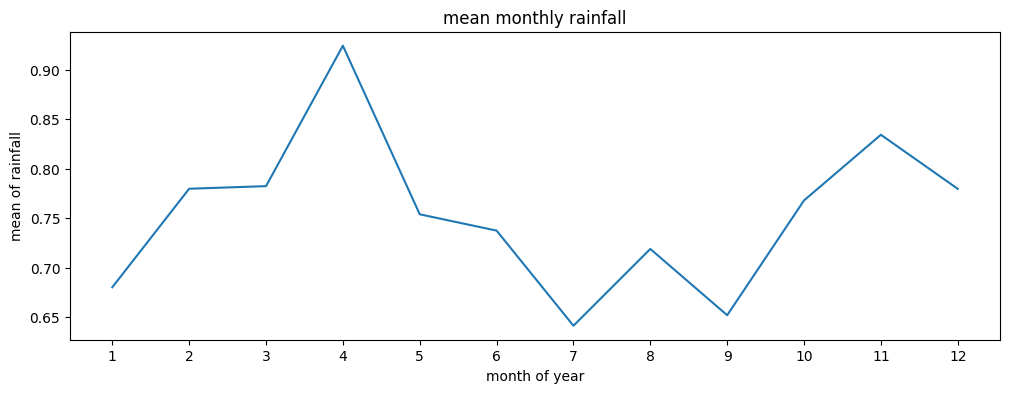

In [48]:
df_month = train_df.copy()
df_month['month'] = pd.to_datetime(df_month['day'], format='%j').dt.month
fig, ax = plt.subplots(figsize=(12, 4))
average_day_rainfall = df_month.groupby(["month"])["rainfall"].mean()
average_day_rainfall.plot(ax=ax)
_ = ax.set(
    title="mean monthly rainfall",
    xticks=[i  for i in range(1,13)],
    #xticklabels=["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"],
    xlabel="month of year",
    ylabel="mean of rainfall",
)

In [ ]:
df_month.groupby(["month"])["rainfall"].sum(), df_month.value_counts("month")

In [49]:
humidity_q1 = train_df.humidity.quantile(0.25)
humidity_q3 = train_df.humidity.quantile(0.75)
humidity_mean = train_df.humidity.quantile(0.5)
humidity_iqr = humidity_q3 - humidity_q1

humidity_lower_bound = humidity_q1 - (1.5 * humidity_iqr)
humidity_upper_bound = humidity_q3 + (1.5 * humidity_iqr)
print(humidity_q1, humidity_mean, humidity_lower_bound,  humidity_upper_bound)
#train_df[(train_df.humidity < humidity_lower_bound) | (train_df.humidity > humidity_upper_bound)].shape

77.0 82.0 60.5 104.5


In [50]:
pressure_q1 = train_df.pressure.quantile(0.25)
pressure_q3 = train_df.pressure.quantile(0.74)
pressure_iqr = pressure_q3 - pressure_q1
pressure_lower_bound = pressure_q1 - (1.5 * pressure_iqr)
pressure_upper_bound = pressure_q3 + (1.5 * pressure_iqr)
print(pressure_lower_bound, pressure_upper_bound)

994.95 1031.3500000000001


In [51]:
# # mark outliers
def mark_outliers(X):
    df = pd.DataFrame()
    outliers = X[(X.sunshine > 10) & (X.cloud < 60)]
    df["outlier"] = X.index.isin(outliers.index).astype(int)
    # # sanity check
    # train_df.loc[~train_df.index.isin(outliers.index), :].outlier.sum()
    return df

In [54]:
X = train_df.copy()

y = X.pop("rainfall")

In [55]:
# check correlations
X.corrwith(y)
# humidity, cloud, sunshine and windspeed have the strongest correlations

day             -0.000462
pressure        -0.049886
maxtemp         -0.079304
temperature     -0.049660
mintemp         -0.026841
dewpoint         0.081965
humidity         0.454213
cloud            0.641191
sunshine        -0.555287
winddirection   -0.006939
windspeed        0.111625
dtype: float64

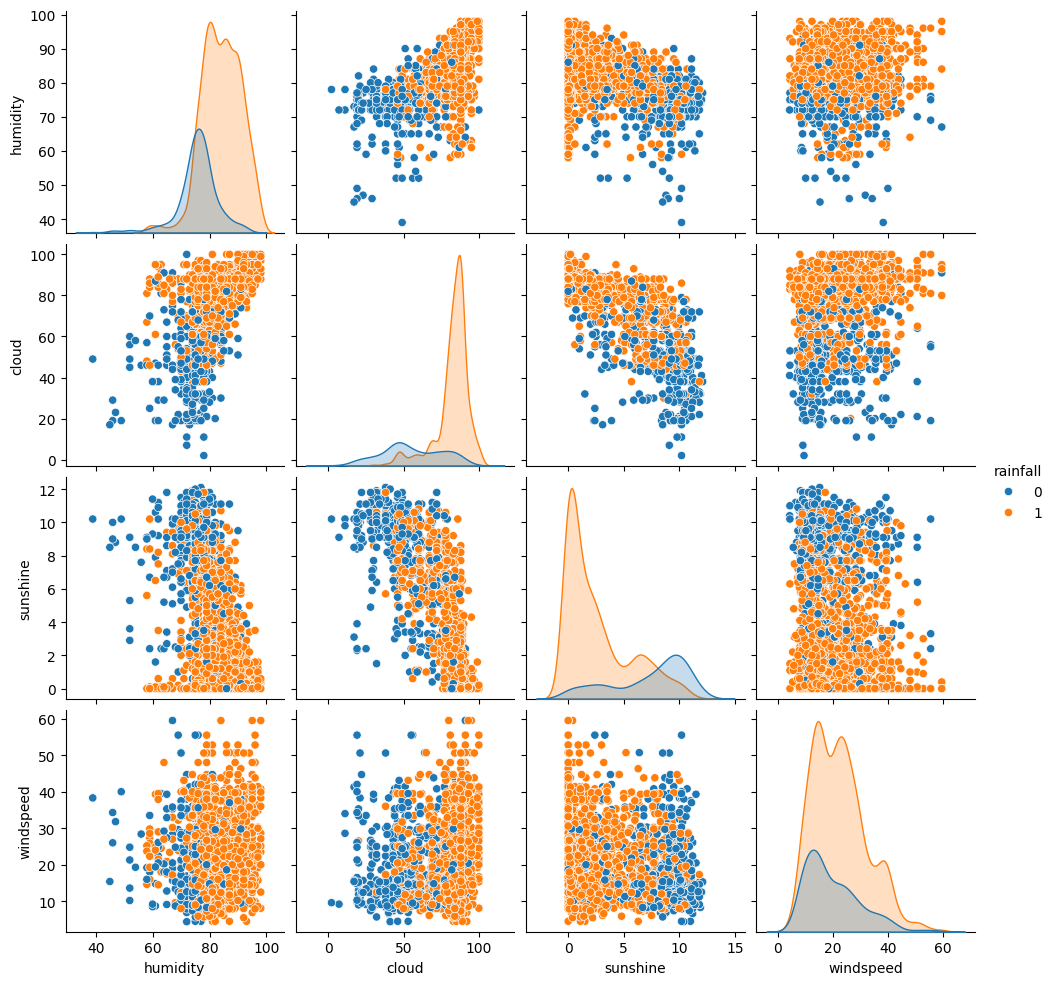

In [56]:
# check pairplots of highest correlations
top_features = ["humidity", "cloud", "sunshine", "windspeed"]
x_top_features = X[top_features].join(y)
sns.pairplot(data=x_top_features, hue="rainfall")
#_ = ax.set(title="Pairplots of highest correlations")
# plt.tight_layout()
plt.show()

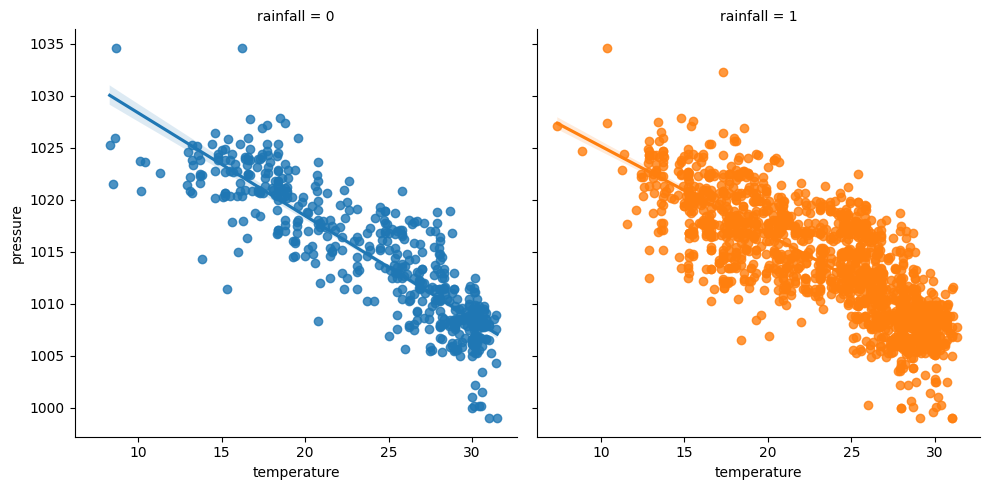

In [57]:
sns.lmplot(x="temperature", y="pressure", data=X.join(y), hue="rainfall", col="rainfall")

<Axes: >

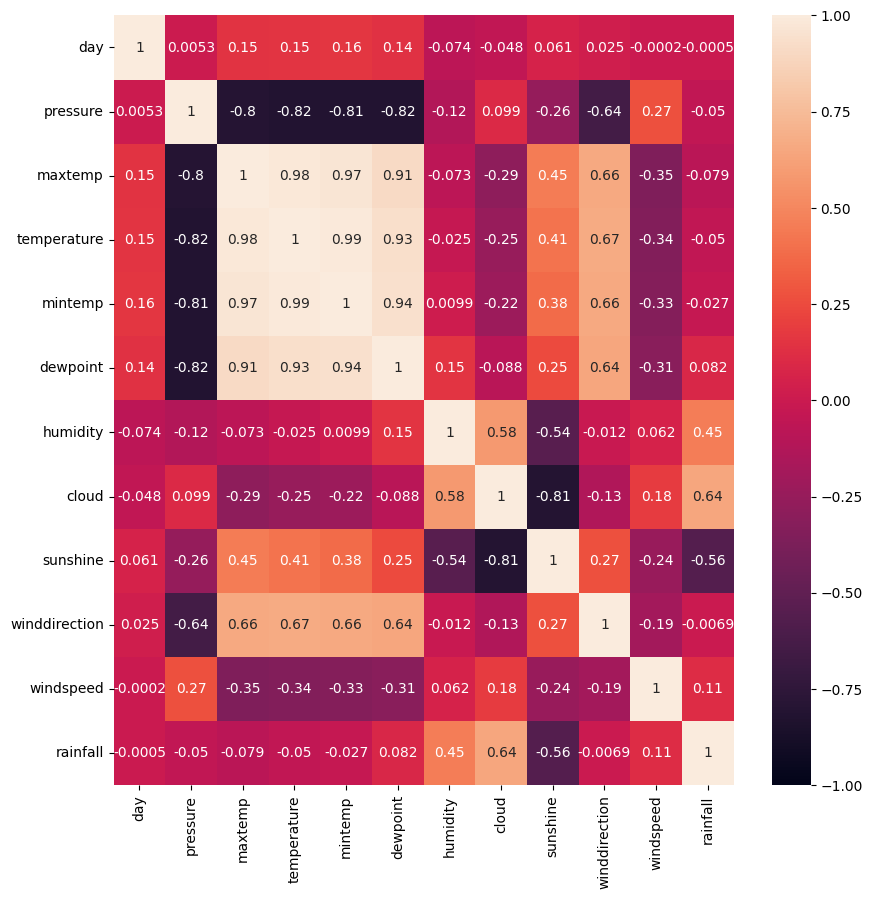

In [58]:
# check all correlations
plt.figure(figsize=(10,10))
sns.heatmap(train_df.corr().map(round,  ndigits=4), vmin=-1, vmax=1, annot=True)

# Feature Utility Scores

In [60]:
X.dtypes

day                int64
pressure         float64
maxtemp          float64
temperature      float64
mintemp          float64
dewpoint         float64
humidity         float64
cloud            float64
sunshine         float64
winddirection    float64
windspeed        float64
dtype: object

In [59]:
discrete_features = X.select_dtypes(include=['int64'])
discrete_features.head()

,day
id,
0,1
1,2
2,3
3,4
4,5


In [61]:
def get_mutual_info_scores(X, y, discrete_features):
  x_scaled = X.select_dtypes(["float"])
  #x_scaled = StandardScaler().fit_transform(x_scaled)
  x_scaled = (x_scaled - x_scaled.mean(axis = 0)) / x_scaled.std(axis = 0)
  df = pd.concat([x_scaled, discrete_features], axis=1)
  scores = mutual_info_classif(X, y, discrete_features=X.columns.isin(discrete_features.columns))
  return scores

def drop_uninformative(df, mi_scores):
    return df.loc[:, mi_scores > 0.0]

In [62]:
mi_scores = get_mutual_info_scores(X,y,discrete_features)
mi_scores_df = pd.DataFrame(mi_scores, index=X.columns, columns=['mutual_info_score'])
mi_scores_df = mi_scores_df.sort_values(by = 'mutual_info_score', ascending=False)
mi_scores_df

,mutual_info_score
cloud,0.212322
day,0.159690
sunshine,0.151276
humidity,0.140317
temperature,0.029978
maxtemp,0.018669
dewpoint,0.018442
pressure,0.016620
mintemp,0.016323
winddirection,0.007465


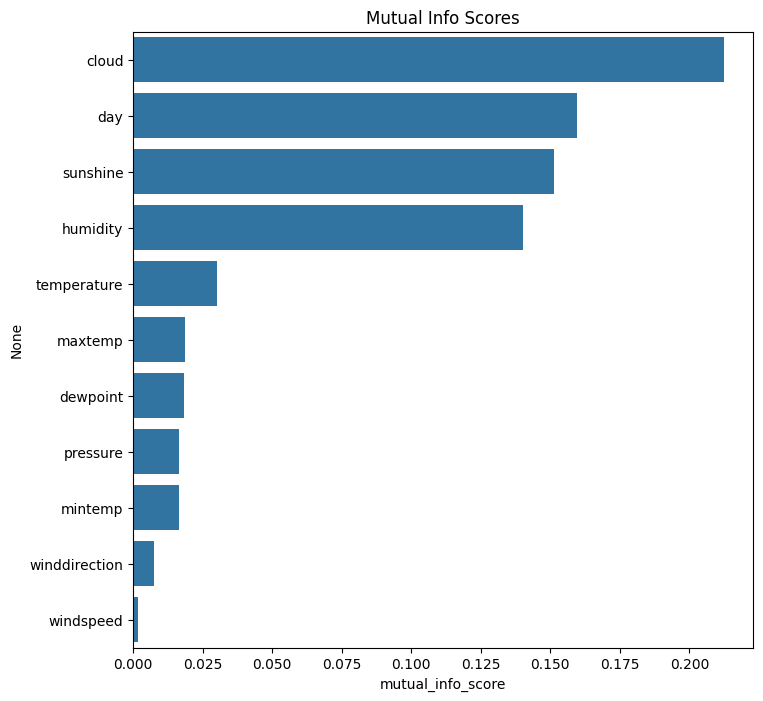

In [63]:
plt.figure(figsize=(8,8))
ax = sns.barplot(y = mi_scores_df.index, x = mi_scores_df.mutual_info_score, orient="h")
ax.set_title("Mutual Info Scores")
plt.show()

In [ ]:
def cluster_labels(df, n_clusters = 5):
  X = df.copy()
  kmeans = KMeans(n_clusters=n_clusters, n_init=50)
  x_scaled = X #X.select_dtypes(include=['float'])
  x_scaled = (x_scaled - x_scaled.mean(axis = 0)) / x_scaled.std(axis = 0) # StandardScaler().fit_trasnform(x_scaled)
  X_new = pd.DataFrame()
  X_new.loc[:, "cluster"] = kmeans.fit_predict(x_scaled)
  X_new["cluster"] = X_new["cluster"].astype("category")
  #############
  # add also the distances from the cluster as a new column
  X_cd = kmeans.fit_transform(x_scaled)
  # Label features and join to dataset
  X_cd = pd.DataFrame(X_cd, columns=[f"Centroid_{i}" for i in range(X_cd.shape[1])], index = df.index)
  ###########
  return X_new, X_cd, kmeans.inertia_

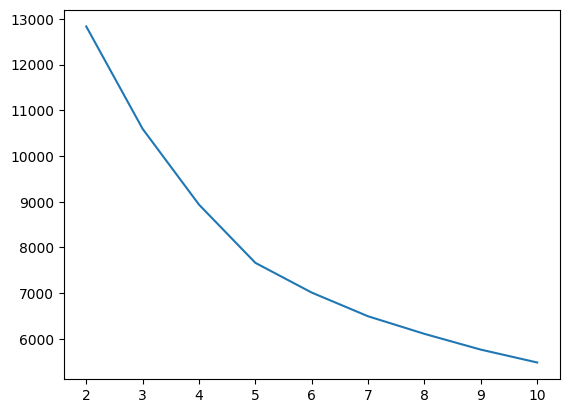

In [65]:
inertia = []
for i in range(2,11):
  X = train_df.copy() 
  X.drop(columns=["day"], inplace=True)
  y = X.pop('rainfall')
  X_new, X_cd, inertia_ = cluster_labels(X, i)
  inertia.append(inertia_)
plt.plot(range(2,11), inertia)
plt.show()

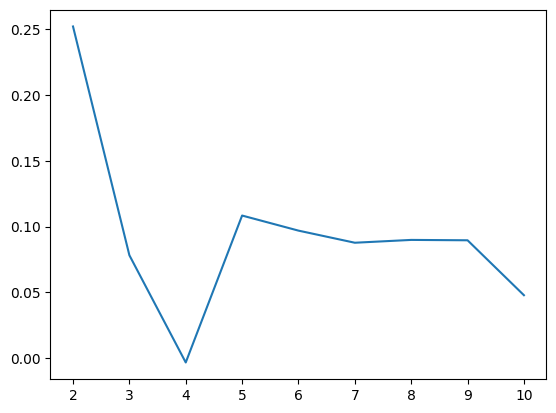

In [66]:
sil_score = []
for i in range(2,11):
  X = train_df.copy() 
  X.drop(columns=["day"], inplace=True)
  y = X.pop('rainfall')
  X_new, X_cd, inertia_ = cluster_labels(X, i)
  sil_score.append(metrics.silhouette_score(X, X_new.cluster.values))
plt.plot(range(2,11), sil_score)
plt.show()

In [67]:
X = train_df.copy()
X.drop(columns=["day"], inplace=True)
y = X.pop('rainfall')
X_new, X_cd, inertia = cluster_labels(X, 5)
X = X.join([X_new, X_cd])

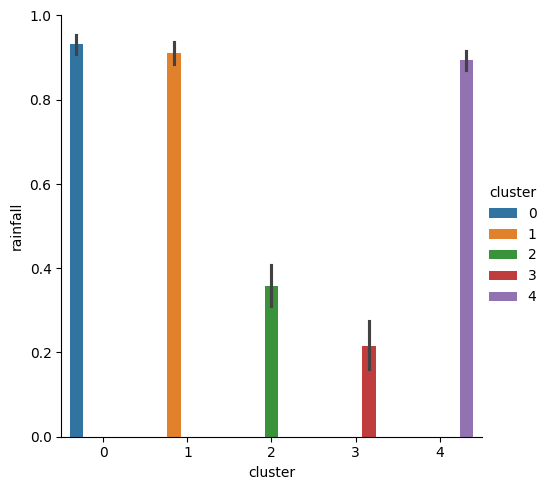

In [68]:
sns.catplot(data=pd.concat([X,y], axis=1), x="cluster", y="rainfall", hue="cluster", kind="bar")

# Target Encode from Day /  Month

In [69]:
class CrossFoldEncoder:
    def __init__(self, encoder, **kwargs):
        self.encoder_ = encoder
        self.kwargs_ = kwargs  # keyword arguments for the encoder
        self.cv_ = KFold(n_splits=5)

    # Fit an encoder on one split and transform the feature on the
    # other. Iterating over the splits in all folds gives a complete
    # transformation. We also now have one trained encoder on each
    # fold.
    def fit_transform(self, X, y, cols):
        self.fitted_encoders_ = []
        self.cols_ = cols
        X_encoded = []
        for idx_encode, idx_train in self.cv_.split(X):
            fitted_encoder = self.encoder_(cols=cols, **self.kwargs_)
            #fit on 1 fold
            fitted_encoder.fit(
                X.iloc[idx_encode, :], y.iloc[idx_encode],
            )
            #transform the other fold
            X_encoded.append(fitted_encoder.transform(X.iloc[idx_train, :])[cols])
            self.fitted_encoders_.append(fitted_encoder)
        X_encoded = pd.concat(X_encoded)
        X_encoded.columns = [name + "_encoded" for name in X_encoded.columns]
        return X_encoded

    # To transform the test data, average the encodings learned from
    # each fold.
    def transform(self, X):
        from functools import reduce

        X_encoded_list = []
        for fitted_encoder in self.fitted_encoders_:
            X_encoded = fitted_encoder.transform(X)
            X_encoded_list.append(X_encoded[self.cols_])
        X_encoded = reduce(
            lambda x, y: x.add(y, fill_value=0), X_encoded_list
        ) / len(X_encoded_list)
        X_encoded.columns = [name + "_encoded" for name in X_encoded.columns]
        return X_encoded

In [70]:
def target_encode(df,col,target):
  X = df.copy()
  #X['month'] = pd.to_datetime(X['day'], format='%j').dt.month
  y = X.pop(target)
  encoder = CrossFoldEncoder(MEstimateEncoder, m=1)
  X_encoded = encoder.fit_transform(X, y, cols=[col])
  return X_encoded

In [71]:
def day_to_Month(df):
  dt = pd.DataFrame()
  dt['month'] = pd.to_datetime(df['day'], format='%j').dt.month
  return dt

# Helper Functions

In [73]:
def make_results(model_name:str, model_object, metric:str):
    '''
    Arguments:
        model_name (string): what you want the model to be called in the output table
        model_object: a fit GridSearchCV object
        metric (string): precision, recall, f1, accuracy, or auc

    Returns a pandas df with the F1, recall, precision, accuracy, and auc scores
    for the model with the best mean 'metric' score across all validation folds.
    '''

    # Create dictionary that maps input metric to actual metric name in GridSearchCV
    metric_dict = {'auc': 'mean_test_roc_auc',
                   'precision': 'mean_test_precision',
                   'recall': 'mean_test_recall',
                   'f1': 'mean_test_f1',
                   'accuracy': 'mean_test_accuracy'
                  }

    # Get all the results from the CV and put them in a df
    cv_results = pd.DataFrame(model_object.cv_results_)

    # Isolate the row of the df with the max(metric) score
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]

    # Extract Accuracy, precision, recall, and f1 score from that row
    auc = best_estimator_results.mean_test_roc_auc
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy

    # Create table of results
    table = pd.DataFrame()
    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'F1': [f1],
                          'accuracy': [accuracy],
                          'auc': [auc]
                        })

    return table

In [75]:
def get_scores(model_name:str, model, X_test_data, y_test_data):
    '''
    Generate a table of test scores.

    In: 
        model_name (string):  How you want your model to be named in the output table
        model:                A fit GridSearchCV object
        X_test_data:          numpy array of X_test data
        y_test_data:          numpy array of y_test data

    Out: pandas df of precision, recall, f1, accuracy, and AUC scores for your model
    '''

    preds = model.best_estimator_.predict(X_test_data)
    preds_proba = model.best_estimator_.predict_proba(X_test_data)[:,1]
    
    auc = metrics.roc_auc_score(y_test_data, preds_proba) #use preds_proba for roc_auc_score
    
    accuracy = metrics.accuracy_score(y_test_data, preds)
    precision = metrics.precision_score(y_test_data, preds)
    recall = metrics.recall_score(y_test_data, preds)
    f1 = metrics.f1_score(y_test_data, preds)

    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision], 
                          'recall': [recall],
                          'f1': [f1],
                          'accuracy': [accuracy],
                          'AUC': [auc]
                         })
  
    return table

# Prepare DataSets for Analysis and Testing

In [76]:
def mathematical_transforms(X):
    df = pd.DataFrame()
    return df

In [78]:
def interactions(X):
    df = pd.DataFrame()
    df["dewpoint_temperature"] = (X.dewpoint + X.temperature) * X.humidity
    return df

In [79]:
def create_features(df, df_test = None):
    X = df.copy()
    y = X.pop("rainfall")
    discrete_features = X.select_dtypes(include=["int64"])
    mi_scores = get_mutual_info_scores(X, y, discrete_features)

    # Combine splits if test data is given
    #
    # If we're creating features for test set predictions, we should
    # use all the data we have available. After creating our features,
    # we'll recreate the splits.
    if df_test is not None:
        X_test = df_test.copy()
        #X_test.pop("rainfall") # there is no response variable in the test set
        X = pd.concat([X, X_test])

    # Mutual Information
    X = drop_uninformative(X, mi_scores)
    X = X.drop(columns=["mintemp", "maxtemp", "winddirection"], errors="ignore")

    # Transformations
    # X = X.join(mathematical_transforms(X))
    X = X.join(interactions(X))
    # X = X.join(counts(X))
    # # X = X.join(break_down(X))
    # X = X.join(group_transforms(X))
    #X = X.join(day_to_Month(X))
    X = X.join(mark_outliers(X))

    #  Clustering
    clusters_labels, cluster_distances, inertia =  cluster_labels(X, n_clusters = 5)
    #X = X.join(clusters_labels)
    X = X.join(cluster_distances)

    # Lesson 5 - PCA
    # X = X.join(pca_inspired(X))
    # X = X.join(pca_components(X, pca_features)) #add the loadings as columns
    # X = X.join(indicate_outliers(X))

    #X = label_encode(X)

    # Reform splits
    if df_test is not None:
        X_test = X.loc[df_test.index, :]
        X.drop(df_test.index, inplace=True)

    # Lesson 6 - Target Encoder
    encoder = CrossFoldEncoder(MEstimateEncoder, m=1)
    X = X.join(encoder.fit_transform(X, y, cols=["day"]))
    X.drop(columns=["day", "month"], inplace=True, errors="ignore")

    if df_test is not None:
        X_test = X_test.join(encoder.transform(X_test))
        X_test.drop(columns=["day", "month"], inplace=True, errors = "ignore")

    if df_test is not None:
        return X, X_test
    else:
        return X


In [80]:
df_train, df_test = load_data()
X_train = create_features(df_train)
y_train = df_train.loc[:, "rainfall"]

In [81]:
X_train.head()

,pressure,temperature,dewpoint,humidity,cloud,sunshine,windspeed,dewpoint_temperature,outlier,Centroid_0,Centroid_1,Centroid_2,Centroid_3,Centroid_4,day_encoded
id,,,,,,,,,,,,,,,
0,1017.4,20.6,19.4,87.0,88.0,1.1,17.2,3480.0,0,3.582504,2.613898,3.905649,6.419754,2.100626,0.951826
1,1019.5,16.9,15.4,95.0,91.0,0.0,21.9,3068.5,0,3.717348,3.773587,5.170064,7.318304,2.052538,0.951826
2,1024.1,16.1,9.3,75.0,47.0,8.3,18.1,1905.0,0,4.618770,5.992272,5.391984,6.409684,3.232816,0.793189
3,1013.4,17.8,16.8,95.0,95.0,0.0,35.6,3287.0,0,3.980205,3.564516,5.108718,7.372833,2.563302,0.626522
4,1021.8,18.4,9.6,52.0,45.0,3.6,24.8,1456.0,0,5.654691,7.077762,6.355039,7.169380,4.643122,0.959855


In [82]:
tr_x, vl_x, tr_y, vl_y = train_test_split(X_train, y_train, test_size=0.25, random_state=0, stratify = y_train)

# Logistic Regression

<Axes: xlabel='humidity', ylabel='rainfall'>

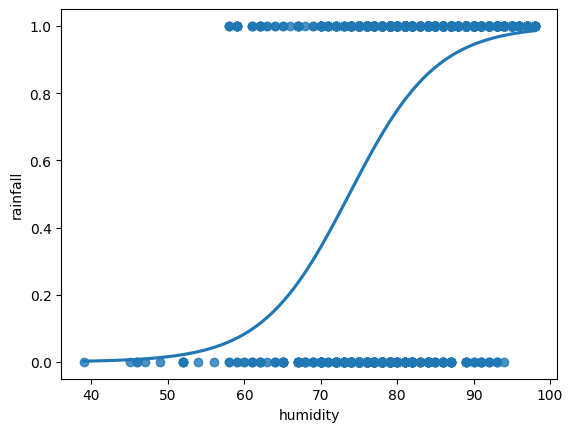

In [83]:
sns.regplot(x="humidity", y="rainfall", data = train_df, logistic = True, ci=None)

<Axes: xlabel='cloud', ylabel='rainfall'>

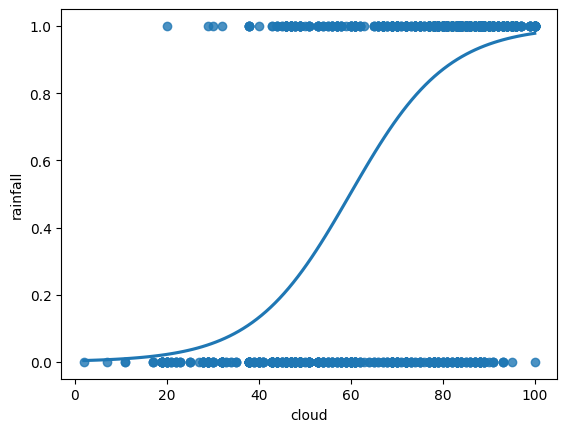

In [84]:
sns.regplot(x="cloud", y="rainfall", data = train_df, logistic = True, ci=None)

<Axes: xlabel='sunshine', ylabel='rainfall'>

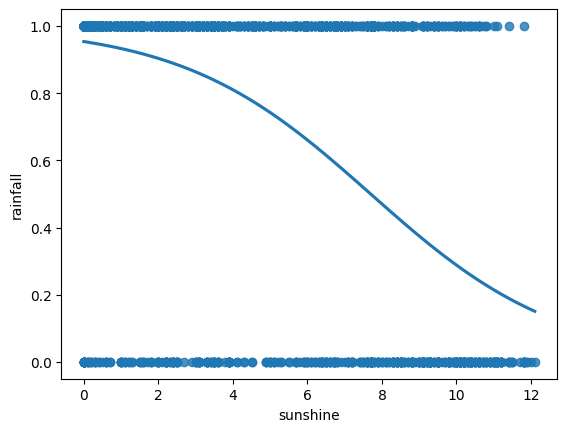

In [85]:
sns.regplot(x="sunshine", y="rainfall", data = train_df, logistic = True, ci=None)

In [ ]:
#sns.regplot(x="dewpoint_temperature", y="rainfall", data = X_train.join(y_train), logistic=True, ci=False)

## Check Regression Assumptions

In [86]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import statsmodels.api as sm
from patsy import dmatrices

### Check Multicolinearity


In [87]:
# Define the predictor variables
test1 = X_train.copy()[["cloud", "humidity", "sunshine", "day_encoded", "dewpoint_temperature"]]
# Add a constant to the model (intercept)
test1 = add_constant(test1)

# Calculate VIF for each feature
datacamp_vif_data = pd.DataFrame()
datacamp_vif_data['Feature'] = test1.columns
datacamp_vif_data['VIF'] = [variance_inflation_factor(test1.values, i) for i in range(test1.shape[1])]
print(datacamp_vif_data)

                Feature         VIF
0                 const  221.404112
1                 cloud    3.164092
2              humidity    2.104265
3              sunshine    3.359121
4           day_encoded    1.094852
5  dewpoint_temperature    1.447050


In [88]:
y1,X1 = dmatrices('rainfall ~ cloud + humidity + sunshine + day_encoded + dewpoint_temperature', data = tr_x.join(tr_y), return_type = 'dataframe')
mod = sm.Logit(y1,X1)
res = mod.fit()
print(res.summary())

Optimization terminated successfully.
         Current function value: 0.339910
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               rainfall   No. Observations:                 1642
Model:                          Logit   Df Residuals:                     1636
Method:                           MLE   Df Model:                            5
Date:                Mon, 02 Mar 2026   Pseudo R-squ.:                  0.3915
Time:                        11:55:14   Log-Likelihood:                -558.13
converged:                       True   LL-Null:                       -917.26
Covariance Type:            nonrobust   LLR p-value:                5.528e-153
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -6.4548      1.153     -5.599      0.000      -8.714      -4.195

In [89]:
y2,X2 = dmatrices('rainfall ~ cloud + sunshine + day_encoded + humidity', data = tr_x.join(tr_y), return_type = 'dataframe')
mod2 = sm.Logit(y2,X2)
res2 = mod2.fit()
print(res2.summary())

Optimization terminated successfully.
         Current function value: 0.347967
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               rainfall   No. Observations:                 1642
Model:                          Logit   Df Residuals:                     1637
Method:                           MLE   Df Model:                            4
Date:                Mon, 02 Mar 2026   Pseudo R-squ.:                  0.3771
Time:                        11:55:28   Log-Likelihood:                -571.36
converged:                       True   LL-Null:                       -917.26
Covariance Type:            nonrobust   LLR p-value:                2.077e-148
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -8.5066      1.111     -7.658      0.000     -10.684      -6.330
cloud           0.0590    

In [90]:
res2.params

Intercept     -8.506577
cloud          0.058987
sunshine      -0.109803
day_encoded    0.834822
humidity       0.066636
dtype: float64

In [ ]:
fitted_values = X2@res2.params
fitted_values[0:5], res2.fittedvalues[0:5]

### Check linear relationship between logit and response varialbes

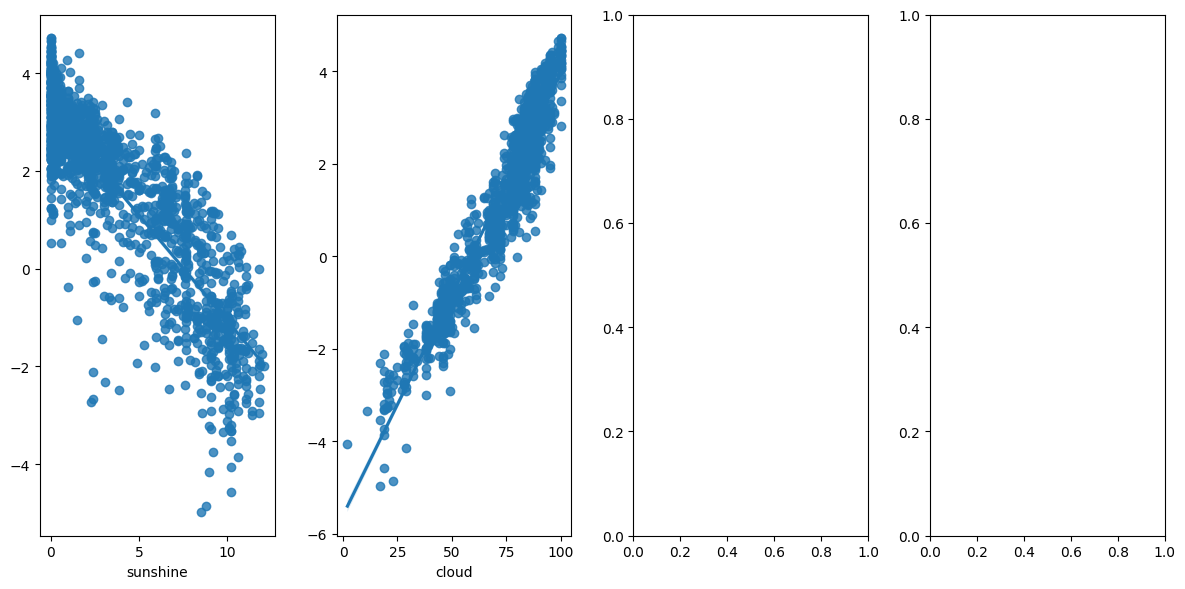

In [91]:
fig, ax = plt.subplots(1,4, figsize=(12,6))
sns.regplot(x=X2.sunshine, y=res2.fittedvalues, ax=ax[0])
sns.regplot(x=X2.cloud, y=res2.fittedvalues, ax = ax[1])
#sns.regplot(x=X1.humidity, y=res.fittedvalues, ax= ax[2])
#sns.regplot(x=X2.dewpoint_temperature, y=res2.fittedvalues, ax= ax[3]) # this is not linear!!!

plt.tight_layout()
plt.show()

## Logistic Regression with L1 penalty

In [92]:
from sklearn.linear_model import LogisticRegression

In [93]:
features = ["cloud", "sunshine", "day_encoded", "dewpoint_temperature", "humidity"]

In [94]:
lr = LogisticRegression(penalty = 'l1', max_iter=5000, solver="liblinear",random_state=0)
clf = lr.fit(tr_x[features], tr_y)

/home/fanyak/sandbox/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/fanyak/sandbox/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [95]:
pd.DataFrame(clf.coef_, columns = features)

,cloud,sunshine,day_encoded,dewpoint_temperature,humidity
0,0.055533,-0.212678,0.637401,0.000635,0.00283


In [96]:
pd.Series([clf.score(tr_x[features], tr_y)], name = "mean accuracy", index=["clf"])

clf    0.861754
Name: mean accuracy, dtype: float64

In [97]:
y_pred = clf.predict(vl_x[features])
metrics.roc_auc_score(y_pred, vl_y)

0.8539696014229122

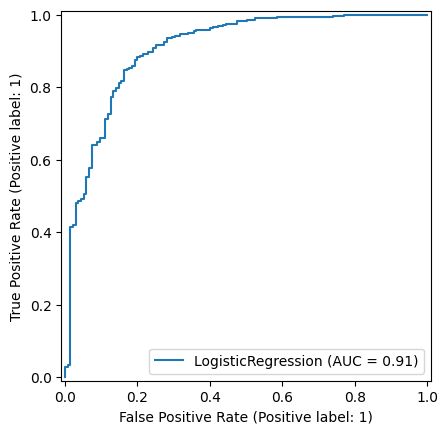

In [98]:
metrics.RocCurveDisplay.from_estimator(clf, vl_x[features], vl_y)

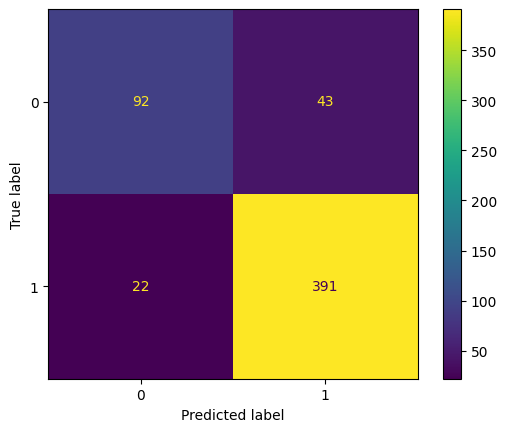

In [99]:
clf_conf_m = metrics.confusion_matrix(vl_y, y_pred, labels=clf.classes_)
disp = metrics.ConfusionMatrixDisplay(clf_conf_m, display_labels = clf.classes_)
disp.plot(values_format='')

## Logistic Regression with L1 and GridSearch Cross Validation

In [ ]:
clf2 = LogisticRegression(penalty='l1', solver='liblinear', max_iter=2000,  random_state = 0)
scoring = scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

x_tr_scaled = tr_x.copy()
x_tr_scaled = (x_tr_scaled - x_tr_scaled.mean(axis = 0)) / x_tr_scaled.std(axis = 0) # StandardScaler().fit_trasnform(x_scaled)

clf2_cv = GridSearchCV(clf2, param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}, scoring=scoring, cv=5, refit="roc_auc")
clf2_cv.fit(x_tr_scaled, tr_y)

In [102]:
clf2_cv.best_score_

np.float64(0.8886893216406516)

In [103]:
pd.DataFrame(clf2_cv.best_estimator_.coef_[0], clf2_cv.feature_names_in_, columns=["coef"])

,coef
pressure,-0.075850
temperature,0.000000
dewpoint,0.338875
humidity,0.270036
cloud,1.004257
sunshine,-0.577176
windspeed,0.032236
dewpoint_temperature,0.000000
outlier,0.000000
Centroid_0,0.000000


In [104]:
make_results('logistic regression cv', clf2_cv, 'auc')

,model,precision,recall,F1,accuracy,auc
0,logistic regression cv,0.88399,0.936143,0.909299,0.859328,0.888689


In [105]:
x_vl_scaled = vl_x.copy()
x_vl_scaled = (x_vl_scaled - x_vl_scaled.mean(axis = 0)) / x_vl_scaled.std(axis = 0) # StandardScaler().fit_trasnform(x_scaled)
get_scores('logistic_regression validation scores', clf2_cv, x_vl_scaled, vl_y)

,model,precision,recall,f1,accuracy,AUC
0,logistic_regression validation scores,0.902778,0.94431,0.923077,0.881387,0.908762


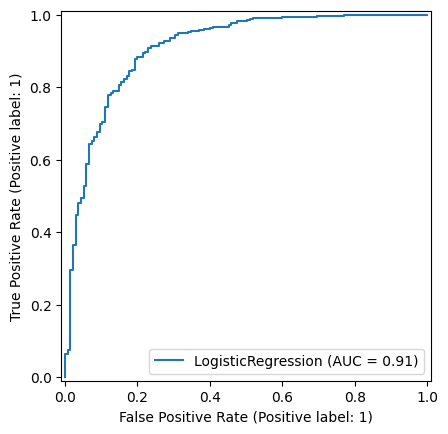

In [106]:
metrics.RocCurveDisplay.from_estimator(clf2_cv.best_estimator_, x_vl_scaled, vl_y)

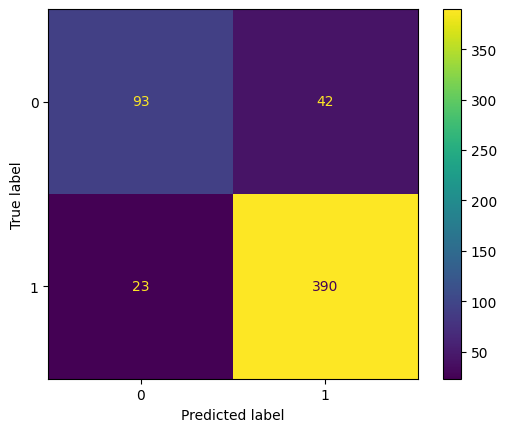

In [107]:
lr_conf_m = metrics.confusion_matrix(vl_y, clf2_cv.best_estimator_.predict(x_vl_scaled), labels = clf2_cv.best_estimator_.classes_)
disp = metrics.ConfusionMatrixDisplay(lr_conf_m, display_labels = clf2_cv.best_estimator_.classes_)
disp.plot(values_format='')

In [108]:
FPR = 17/(74+17)
TPR = 313/(313+17)
TPR,FPR 

(0.9484848484848485, 0.18681318681318682)

In [109]:
target_names = ['Predicted would not rain', 'Predicted would rain']
print(metrics.classification_report(vl_y, clf2_cv.best_estimator_.predict(x_vl_scaled), target_names=target_names))

                          precision    recall  f1-score   support

Predicted would not rain       0.80      0.69      0.74       135
    Predicted would rain       0.90      0.94      0.92       413

                accuracy                           0.88       548
               macro avg       0.85      0.82      0.83       548
            weighted avg       0.88      0.88      0.88       548



# Tree Methods

In [110]:
df_train, df_test = load_data()
X_train = create_features(df_train)
y_train = df_train.loc[:, "rainfall"]

In [111]:
tr_x, vl_x, tr_y, vl_y = train_test_split(X_train, y_train, test_size=0.25, stratify=y_train, random_state=0)

In [112]:
tr_x.head()

,pressure,temperature,dewpoint,humidity,cloud,sunshine,windspeed,dewpoint_temperature,outlier,Centroid_0,Centroid_1,Centroid_2,Centroid_3,Centroid_4,day_encoded
id,,,,,,,,,,,,,,,
2080,1007.3,28.0,25.0,86.0,83.0,0.9,52.8,4558.0,0,3.493350,4.367085,4.764664,5.436487,7.036261,0.624049
1395,1013.7,24.4,19.9,91.0,74.0,3.1,38.0,4031.3,0,2.718662,3.728654,4.164329,3.135617,6.213366,0.792333
1883,1012.0,21.3,19.9,79.0,88.0,2.0,26.8,3254.8,0,2.310116,3.216057,3.131904,2.100588,5.971489,0.957382
947,1008.3,29.2,24.0,80.0,85.0,5.3,13.9,4256.0,0,1.618507,1.585158,4.094299,4.662408,5.406172,0.752283
1706,1011.4,28.7,24.5,82.0,84.0,3.6,13.9,4362.4,0,1.289867,1.873528,3.749233,4.546413,5.603310,0.550799


## Decision Tree

In [113]:
from sklearn.tree import DecisionTreeClassifier

In [114]:
tree1 = DecisionTreeClassifier(random_state=0)
cv_params = {'max_depth':[4, 6, 8, 12, None],
             'min_samples_leaf': [2, 5, 6],
             'min_samples_split': [2, 4, 6]
             }
scoring = scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv1 = GridSearchCV(tree1, cv_params, scoring=scoring, refit='roc_auc', cv=5)

In [115]:
cv1.fit(tr_x, tr_y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [4, 6, ...], 'min_samples_leaf': [2, 5, ...], 'min_samples_split': [2, 4, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'precision', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and para

In [116]:
cv1.best_score_

np.float64(0.8444192718032559)

In [117]:
make_results('decision tree fit', cv1, 'auc')

,model,precision,recall,F1,accuracy,auc
0,decision tree fit,0.892215,0.919159,0.905247,0.855071,0.844419


In [118]:
pd.DataFrame(cv1.best_estimator_.feature_importances_, cv1.best_estimator_.feature_names_in_, columns=["importance"]).sort_values(by="importance", ascending = False)

,importance
cloud,0.863733
Centroid_0,0.039778
Centroid_3,0.033122
sunshine,0.024633
humidity,0.015633
Centroid_4,0.007351
dewpoint_temperature,0.006232
Centroid_1,0.005828
dewpoint,0.003690
pressure,0.000000


In [ ]:
get_scores('decision tree validation scores', cv1, vl_x, vl_y)

In [ ]:
metrics.RocCurveDisplay.from_estimator(cv1.best_estimator_,vl_x, vl_y)

In [ ]:
cv1_conf_m = metrics.confusion_matrix(vl_y, cv1.best_estimator_.predict(vl_x), labels = cv1.best_estimator_.classes_)
disp = metrics.ConfusionMatrixDisplay(cv1_conf_m, display_labels = cv1.best_estimator_.classes_)
disp.plot(values_format='')

## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf1 = RandomForestClassifier(random_state=0)
cv_params = {'max_depth': [3,5, None],
             'max_features': [1.0],
             'max_samples': [0.7, 1.0],
             'min_samples_leaf': [1,2,3],
             'min_samples_split': [2,3,4],
             'n_estimators': [300, 500],
             }
cv2 = GridSearchCV(rf1, cv_params, scoring=scoring, refit='roc_auc', cv=5, n_jobs=-1)

In [ ]:
cv2.fit(tr_x, tr_y)

In [ ]:
cv2.best_estimator_, cv2.best_score_

In [ ]:
pd.DataFrame(cv2.best_estimator_.feature_importances_, cv2.best_estimator_.feature_names_in_, columns=["importance"]).sort_values(by="importance", ascending=False)

In [ ]:
make_results('random forest fit', cv2, "auc")

In [ ]:
get_scores("random forest validation scores", cv2, vl_x, vl_y)

In [ ]:
metrics.RocCurveDisplay.from_estimator(cv2.best_estimator_, vl_x, vl_y)

In [ ]:
cv2_conf_m = metrics.confusion_matrix(vl_y, cv2.best_estimator_.predict(vl_x), labels = cv2.best_estimator_.classes_)
disp = metrics.ConfusionMatrixDisplay(cv2_conf_m, display_labels = cv2.best_estimator_.classes_)
disp.plot(values_format = '')

## XGBoost Method

In [ ]:
from xgboost import XGBClassifier, plot_importance

In [ ]:
xgb = XGBClassifier(random_state=0, objective='binary:logistic')

In [ ]:
cv_params = {
    'max_depth': [1,2,4],
    'min_child_weight': [3],
    'learning_rate': [0.01],
    'n_estimators': [500],
    'subsample': [0.7],
    'colsample_bytree': [0.7]
}
cv3 = GridSearchCV(xgb, cv_params, scoring=scoring, refit='roc_auc', cv=5)

In [ ]:
xgb_cv = cv3.fit(tr_x, tr_y)

In [ ]:
xgb_cv.best_estimator_, xgb_cv.best_score_

In [ ]:
make_results('xgboost fit', xgb_cv, 'auc')

In [ ]:
pd.DataFrame(xgb_cv.best_estimator_.feature_importances_, xgb_cv.best_estimator_.feature_names_in_, columns=["importance"]).sort_values(by="importance", ascending=False)

In [ ]:
get_scores('xgboost validation scores', xgb_cv, vl_x, vl_y)

In [ ]:
xgb_cv_onf_m = metrics.confusion_matrix(vl_y, xgb_cv.best_estimator_.predict(vl_x), labels=xgb_cv.best_estimator_.classes_)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=xgb_cv_onf_m, display_labels=xgb_cv.best_estimator_.classes_)
disp.plot(values_format='')
plt.show()

In [ ]:
metrics.RocCurveDisplay.from_estimator(
   xgb_cv.best_estimator_, vl_x, vl_y)

In [ ]:
plot_importance(xgb_cv.best_estimator_)

# Train the best estimater on the entire training set and prepare submission file

In [ ]:
df_train, df_test = load_data()
X_train, X_test = create_features(df_train, df_test)
y_train = df_train.loc[:, "rainfall"]

In [ ]:
cv_params = {
    'max_depth': [1,2,4],
    'min_child_weight': [3],
    'learning_rate': [0.01],
    'n_estimators': [500],
    'subsample': [0.7],
    'colsample_bytree': [0.7]
}
scoring = scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

xgb_fin = XGBClassifier(random_state=42, objective='binary:logistic')

In [ ]:
cv_fin = GridSearchCV(xgb_fin, cv_params, scoring=scoring, refit='roc_auc', cv=5)

In [ ]:
xgb_cv_fin = cv_fin.fit(X_train, y_train)

In [ ]:
make_results('xgboost', xgb_cv_fin, 'auc')

In [ ]:
y_pred = xgb_cv_fin.best_estimator_.predict(X_test)
y_pred_proba = xgb_cv_fin.best_estimator_.predict_proba(X_test)[:, 1]
submission_df = pd.DataFrame({'id': X_test.index.astype(int), 'rainfall': y_pred_proba})
submission_df.to_csv('/kaggle/working/submission.csv', index=False)